# Dynamic Conditional Correlation Modelling 

*By Vlad Popa*

Squared returns act as a proxy for time-varying variance $\sigma^2_t$. Autocorrelation in squared returns suggests that volatility tends to cluster over time rather than occur randomly. This phenomenon is known as **volatility clustering**, and plays a significant role in risk management, derivative pricing and algorithmic trading because it proves that market volatility is not entirely random. By means of **observation-driven models**, which estimate unobserved time-varying parameters using lagged dependent variables, volatility clustering can be captured.

This project investigates volatility clustering by assessing the time-varying, conditional correlation between several assets, driven by geopolitical choke points in 2026 using the DCC-GARCH(1,1) model.

## 0. Import Libraries and Load Data

In [1]:
# Import libraries
library(rugarch)
library(rmgarch)
library(purrr)
library(ggplot2)
library(tidyr)
library(reshape2)
library(dplyr)
library(tseries)

# Read .csv files
bdi <- read.csv("input/mod/Modified Baltic Dry Index Historical Data.csv")
oil <- read.csv("input/mod/Modified Crude Oil WTI Futures Historical Data.csv")
soxx <- read.csv("input/mod/Modified SOXX ETF Stock Price History.csv")
urth <- read.csv("input/mod/Modified URTH ETF Stock Price History.csv")
gold <- read.csv("input/mod/Modified XAU_USD Historical Data.csv")

Loading required package: parallel


Attaching package: 'purrr'


The following object is masked from 'package:rugarch':

    reduce



Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths



Attaching package: 'dplyr'


The following objects are masked from 'package:rmgarch':

    first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [2]:
# Save returns of each asset to a separate dataframe
bdi_rets <- data.frame(Date = bdi$Date,  BDI = bdi$Return)
oil_rets <- data.frame(Date = oil$Date,  OIL = oil$Return)
soxx_rets <- data.frame(Date = soxx$Date, SOXX = soxx$Return)
urth_rets <- data.frame(Date = urth$Date, URTH = urth$Return)
gold_rets <- data.frame(Date = gold$Date, GOLD = gold$Return)

# Save all dataframes to a list
rets_list <- list(bdi_rets, oil_rets, soxx_rets, urth_rets, gold_rets)

# Sequentially merge each dataframe on the 'Date' column
returns_scaled <- purrr::reduce(rets_list, merge, by = "Date")
rownames(returns_scaled) <- returns_scaled$Date
returns_scaled$Date <- NULL

## 1. Pre-Diagnostics
In order to justify GARCH modelling, we must confirm stationarity in asset returns using the ADF Test. This involves testing $H_0$: non-stationarity against $H_1$: stationarity, by running linear regression models on given time series data to see if it follows a random walk process. Furthermore, volatility clustering is assessed (indirectly) by testing for autocorrelation in squared returns using the Ljung-Box Test. It tests $H_0$: zero autocorrelation against $H_1$: non-zero autocorrelation, by assessing the "randomness" of data based on a number of lags. 

In [3]:
# Run ADF test on asset returns
apply(returns_scaled, 2, adf.test)

# Test if the squared returns are autocorrelated up to lag 10
ljung_box <- function(returns_scaled){
    for (asset in colnames(returns_scaled)){
        print(asset)
        result <- Box.test(returns_scaled[[asset]]^2, lag = 10, type = "Ljung-Box")
        print(result)
    }
}

print(ljung_box(returns_scaled))

Warning message in FUN(newX[, i], ...):
"p-value smaller than printed p-value"
Warning message in FUN(newX[, i], ...):
"p-value smaller than printed p-value"
Warning message in FUN(newX[, i], ...):
"p-value smaller than printed p-value"
Warning message in FUN(newX[, i], ...):
"p-value smaller than printed p-value"
Warning message in FUN(newX[, i], ...):
"p-value smaller than printed p-value"


$BDI

	Augmented Dickey-Fuller Test

data:  newX[, i]
Dickey-Fuller = -8.2269, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary


$OIL

	Augmented Dickey-Fuller Test

data:  newX[, i]
Dickey-Fuller = -7.8673, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary


$SOXX

	Augmented Dickey-Fuller Test

data:  newX[, i]
Dickey-Fuller = -8.0033, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary


$URTH

	Augmented Dickey-Fuller Test

data:  newX[, i]
Dickey-Fuller = -9.1466, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary


$GOLD

	Augmented Dickey-Fuller Test

data:  newX[, i]
Dickey-Fuller = -7.4361, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary



[1] "BDI"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 38.837, df = 10, p-value = 2.711e-05

[1] "OIL"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 255.16, df = 10, p-value < 2.2e-16

[1] "SOXX"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 70.168, df = 10, p-value = 4.114e-11

[1] "URTH"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 304.97, df = 10, p-value < 2.2e-16

[1] "GOLD"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 47.104, df = 10, p-value = 9.041e-07

NULL


In the output above, we see that each asset has a $p$-value smaller than 0.05 in the ADF Test, indicating that the returns are indeed stationary. Additionally, the squared returns yield $p$-values smaller than 0.05 in the Ljung-Box Test, meaning that they are significantly autocorrelated. We can therefore conclude the presence of volatility clustering, and that GARCH estimation is justified.

## 2. DCC-GARCH Model

The **DCC-GARCH model** is an extended, multivariate variant of an observation-driven model. It computes the conditional covariance matrix $\Sigma_t$ using lagged dependent variables, while also modelling the time-varying conditional correlation between the assets based on their conditional volatility. Unlike other multivariate GARCH models, the DCC extension allows for co-dependencies when computing covariances, a small dimensionality, and a positive definite covariance matrix $\Sigma_t$. We bring the model together in the two sections below.

### 2.a GARCH Modelling

The first step of modelling the DCC-GARCH involves estimating a univariate GARCH model for each asset. In other words, we extract the behaviour of each individual asset's conditional variance. We do so by estimating the Exponential GARCH(1,1) Model (eGARCH(1,1)) on each asset, which also captures any asymmetric leverage effects (using $\gamma_i$) and ensures that an asset's variance never goes negative (though $\ln{(.)}$), as to obtain: $$\ln{(\sigma^2_{i,t})}=\omega_{i}+\beta_{i}\ln{(\sigma^2_{i,t-1})}+\alpha_{i}|\frac{y_{i,t-1}}{\sigma_{i,t-1}}| + \gamma_i \frac{y_{i,t-1}}{\sigma_{i,t-1}} \text{ for each asset } i \text{ in } i = 1,2,...$$

In [4]:
# Function for modelling conditional volatilities using eGARCH
my_garch <- function(returns_scaled){
    # Specify our GARCH model: how do individual variances behave?
    uspec <- ugarchspec(
        mean.model = list(armaOrder = c(0,0), include.mean = FALSE),
        variance.model = list(model = "eGARCH"),
        distribution.model = "std")

    # Replicate the univariate GARCH model across all assets
    mspec <- multispec(replicate(ncol(returns_scaled), uspec))       

    # Estimate all conditional volatilities using our defined GARCH model
    fitlist <- multifit(multispec = mspec, data = returns_scaled)
    sigmas <- sigma(fitlist)
    std_residuals <- residuals(fitlist, standardize = TRUE)
    
    # Save sigmas and std_residuals as dataframes
    rownames(sigmas) <- rownames(returns_scaled)
    colnames(sigmas) <- colnames(returns_scaled)
    sigmas <- as.data.frame(sigmas)

    colnames(std_residuals) <- colnames(returns_scaled)
    std_residuals <- as.data.frame(std_residuals)

    # Save specifications, fits and conditional volatilities together
    output = list(
        sigmas = sigmas,
        mspec = mspec,
        fitlist = fitlist,
        std_residuals = std_residuals
    )
    return(output)
}

# Run function and save conditional volatilites
ugarch_results <- my_garch(returns_scaled) 
sigmas <- ugarch_results[["sigmas"]]
mspec <- ugarch_results[["mspec"]]
fitlist <- ugarch_results[["fitlist"]]
std_residuals <- ugarch_results[["std_residuals"]]

Warning message in .egarchfit(spec = spec, data = data, out.sample = out.sample, :
"
ugarchfit-->warning: solver failer to converge."
Warning message in .egarchfit(spec = spec, data = data, out.sample = out.sample, :
"
ugarchfit-->warning: solver failer to converge."
Warning message in .egarchfit(spec = spec, data = data, out.sample = out.sample, :
"
ugarchfit-->warning: solver failer to converge."


### 2.b DCC Modelling

In this next step, we utilize the univariate eGARCH specifications from the previous section as well as the fitted data for each asset. By means of the DCC framework, we use those outputs as inputs for modelling the dynamic conditional correlation matrix based on standardized returns. In mathematical notation, we compute: 
$$Q_t = (1 - \alpha - \beta)\bar{Q} + \alpha(v_{t-1}v_{t-1}') + \beta Q_{t-1}$$

Where $v_t = \frac{y_t}{\sigma_t}$ represents the vector of standardized returns of all assets, and $\bar{Q}$ is the unconditional covariance matrix of the standardized residuals over the entire sample period. 

To ensure the elements are strictly bounded between $-1$ and $1$, the final conditional correlation matrix $R_t$ is rescaled as:

$$R_t = \text{diag}(Q_t)^{-1/2} Q_t \text{diag}(Q_t)^{-1/2}$$

In [5]:
# Function for modelling dynamic correlations between assets
my_dcc <- function(returns_scaled, mspec, fitlist){
    # Specify our DCC model: how do the correlations behave?
    dcc_spec <- dccspec(uspec = mspec, dccOrder = c(1,1), model = "DCC")
    dcc_fit <- dccfit(spec = dcc_spec, data = returns_scaled, fit = fitlist)
    corr_matrix <- rcor(dcc_fit)
    return (corr_matrix)
}

# Run function and save conditional correlation matrix
corr_matrix <- my_dcc(returns_scaled, mspec, fitlist) 

## 3. Post-Diagnostics
To check whether the eGARCH Model succesfully captured all the volatility clustering, we conduct the Ljung-Box Test on the standardized residuals. These should now be independent and identically distributed (i.e., no autocorrelation) in order to justify our DCC estimation (all heteroskedasticity is "stripped").

In [6]:
# Conduct Ljung-Box Test on standardized residuals
print(ljung_box(std_residuals))

[1] "BDI"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 7.8783, df = 10, p-value = 0.6407

[1] "OIL"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 2.3709, df = 10, p-value = 0.9926

[1] "SOXX"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 17.795, df = 10, p-value = 0.05852

[1] "URTH"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 6.1648, df = 10, p-value = 0.8012

[1] "GOLD"

	Box-Ljung test

data:  returns_scaled[[asset]]^2
X-squared = 19.677, df = 10, p-value = 0.03246

NULL


Post estimation diagnostics reveal that while the eGARCH(1,1) model successfully cleared the residuals of the OIL, BDI, SOXX, and URTH, it left significant serial correlation in Gold's standardized residuals ($p < 0.05$). We can therefore conclude that while model is acceptable, it could not fully capture the nonlinear dynamics of Gold. An explanation for this could be periodic "safe-haven" behaviour of investors complicating estimation. 

## 4. Results
We display the results of our analysis in three plots: 
1. A time series plot displaying the conditional volatility of each asset throughout the data.
2. A time series plot displaying the conditional correlation between each asset throughout the data. 
3. A heat map showcasing the conditional correlation between each asset across Iran-US conflict pre-event, escalation and stabilization.


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


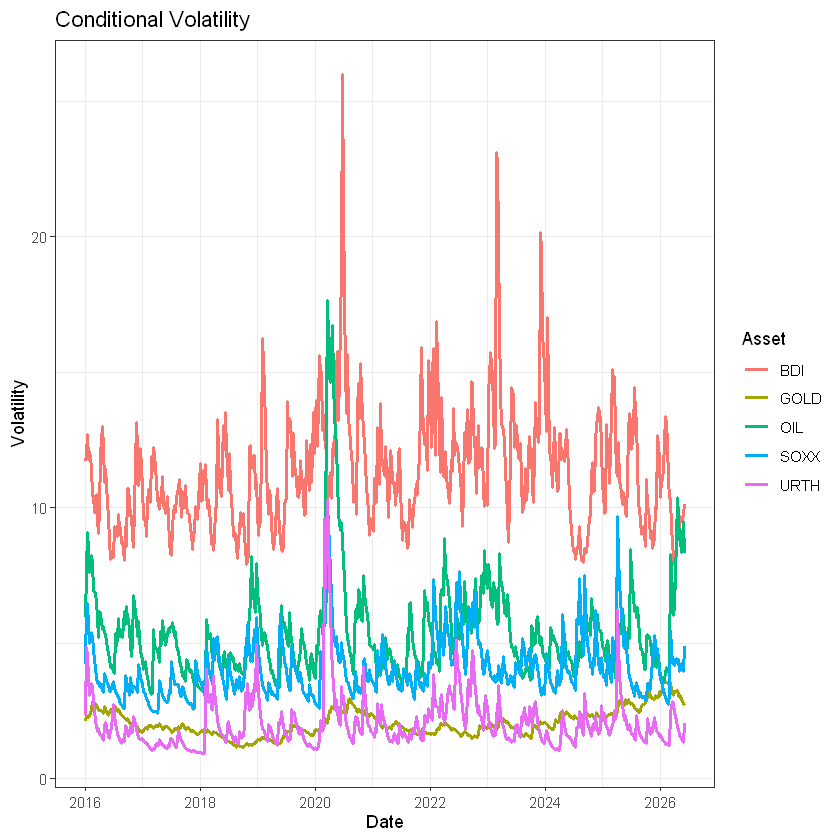

In [7]:
# Convert sigmas dataframe to "longer" dataframe
sigmas$Date <- as.Date(rownames(sigmas))
sigmas_long <- sigmas %>%
    pivot_longer(
        cols = -Date,
        names_to = "Asset",
        values_to = "Var_T"
    )

# Time series plot of conditional variances     
ggplot(sigmas_long, aes(x = Date, y = Var_T, color = Asset)) + 
    labs(title = "Conditional Volatility", x = "Date", y = "Volatility") + 
    geom_line(size = 1) + 
    theme_bw()

The conditional volatility plot illustrates the time-varying standard deviations ($\sigma_t$) estimated via the univariate GARCH processes. From this plot, we can derive the baseline volatility of assets as well as its shock sensitivity. 

When we look at BDI and OIL, we see high volatility as a result of short-term high inelastic supply. During geopolitical regime shifts, such as the COVID-19 pandemic and now the Iran-US conflict, any shocks in supply or shipping routes tend to increase the conditional volatility. 

Gold on the other hand is considered a “safe-haven” asset for investors, as it is highly liquid and serves as a monetary anchor. As a result, the conditional volatility remains low even during economic shocks. 

Finally, we see that URTH and SOXX have similar movements in conditional volatility, which also spikes during regime changes as a consequence of their dependency on international trade. Unlike SOXX which is a sector-based ETF, the URTH ETF is more robust against shocks due to its diversification benefit and reduced asset concentration risk. 


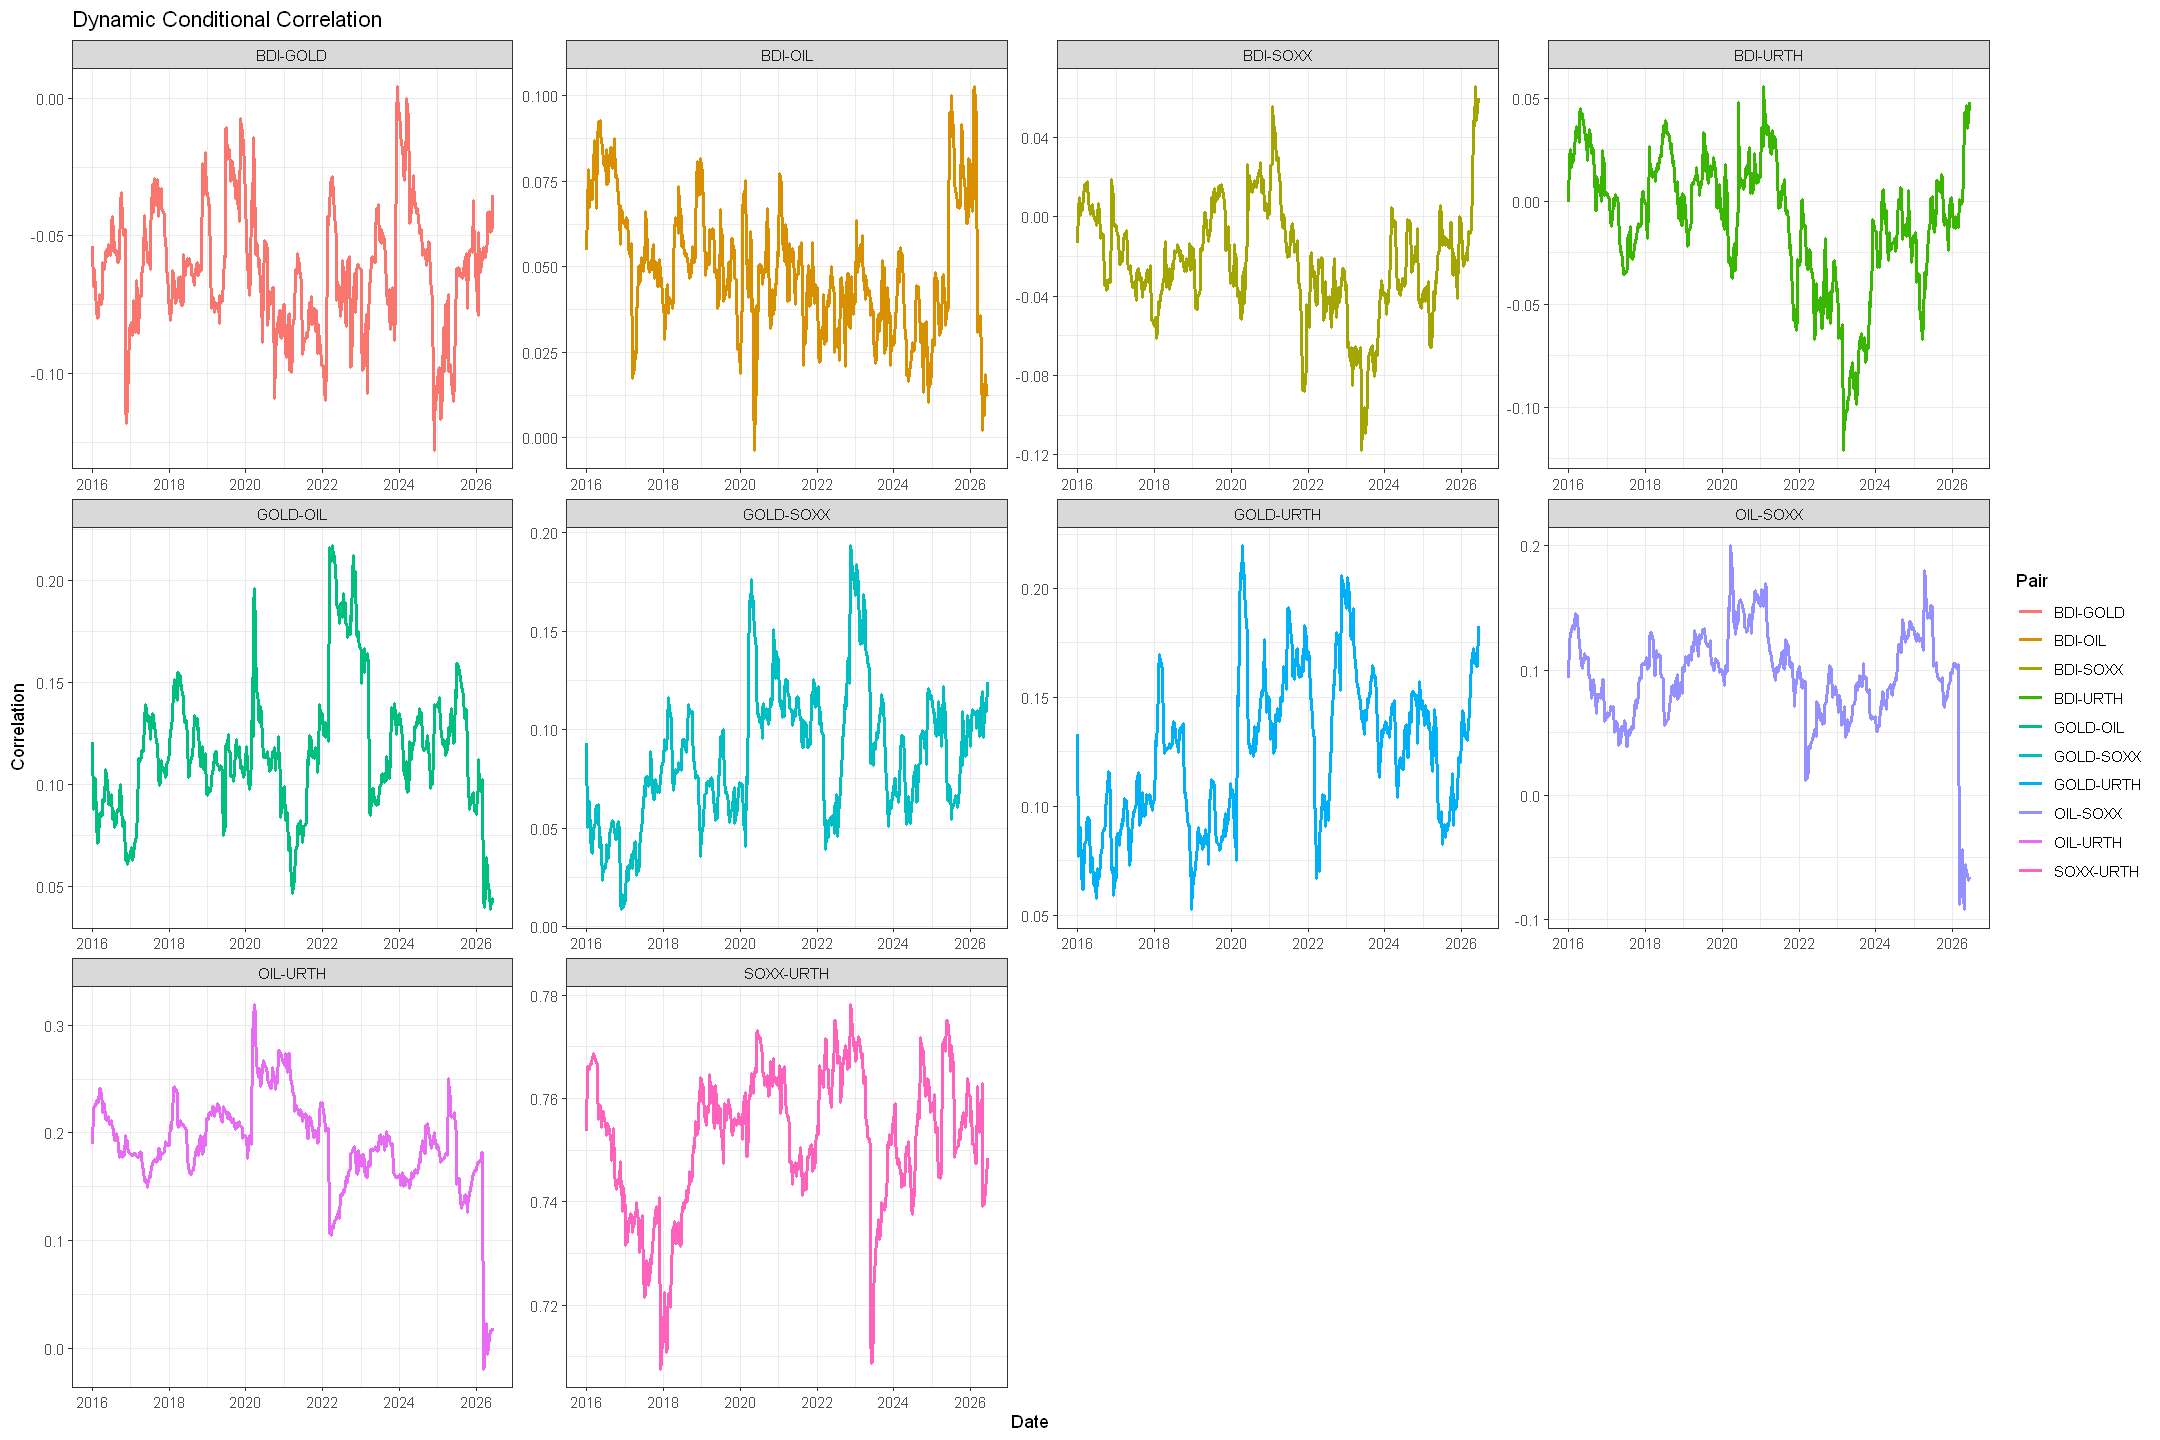

In [8]:
# Melt the correlation matrix
melt_corr_matrix <- melt(corr_matrix)

# Keep upper triangle
Rt_matrix <- subset(melt_corr_matrix, as.character(Var1) < as.character(Var2))

# Save conditional correlations of pairs to new data frame
Rt_matrix <- data.frame(Date = as.Date(Rt_matrix$Var3),
                        Pair = paste(Rt_matrix$Var1, Rt_matrix$Var2, sep="-"),
                        Corr_T = Rt_matrix$value)

# Time series plot of conditional correlation
options(repr.plot.width = 18, repr.plot.height = 12)
ggplot(Rt_matrix, aes(x = Date, y = Corr_T, color = Pair)) + 
    labs(title = "Dynamic Conditional Correlation", x = "Date", y = "Correlation") + 
    geom_line(size = 1) + 
    theme_bw() + 
    facet_wrap(~ Pair, scales = "free")

The DCC-GARCH framework estimates dynamic correlations ($R_t$) over time after accounting for time-varying univariate volatility. 

During the Iran-US conflict window at the start of 2026, we see downward plunges in the conditional correlation in OIL-SOXX and OIL-URTH as a consequence of a supply shock in oil. The negative shift in conditional correlation is consistent with a regime in which rising oil prices coincided with weakening equity performance. Given the diversification benefit of the URTH ETF, this downward effect in correlation is reduced compared to the SOXX ETF.

While the conditional correlation in GOLD-OIL and GOLD-BDI also decreased during this window, it remains persistently positive throughout the 10-year window. This suggests that while the assets act as joint hedges, they could temporarily separate during regime changes as Gold acts as a safe-haven for investors.


In [9]:
# Slice melted correlation matrix by date windows
pre_corr_matrix <- subset(melt_corr_matrix, as.character(Var3) < "2026-02-28")
pre_corr_matrix <- pre_corr_matrix %>%
        group_by(Var1, Var2) %>%
        summarise(mean_corr = mean(value), state = "1. Pre-Event (< 2026-02-28)")

esc_corr_matrix <- subset(melt_corr_matrix, as.character(Var3) > "2026-02-27" & as.character(Var3) < "2026-04-08")
esc_corr_matrix <- esc_corr_matrix %>%
        group_by(Var1, Var2) %>%
        summarise(mean_corr = mean(value), state = "2. Escalation (2026-02-28 - 2026-04-07)")

stb_corr_matrix <- subset(melt_corr_matrix, as.character(Var3) > "2026-04-07")
stb_corr_matrix <- stb_corr_matrix %>%
        group_by(Var1, Var2) %>%
        summarise(mean_corr = mean(value), state = "3. Stabilization (> 2026-04-08)")

# Stack lists vertically
full_corr_matrix <- bind_rows(pre_corr_matrix, esc_corr_matrix, stb_corr_matrix)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Var1 and Var2.
ℹ Output is grouped by Var1.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Var1, Var2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Var1 and Var2.
ℹ Output is grouped by Var1.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Var1, Var2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Var1 and Var2.
ℹ Output is grouped by Var1.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Var1, Var2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


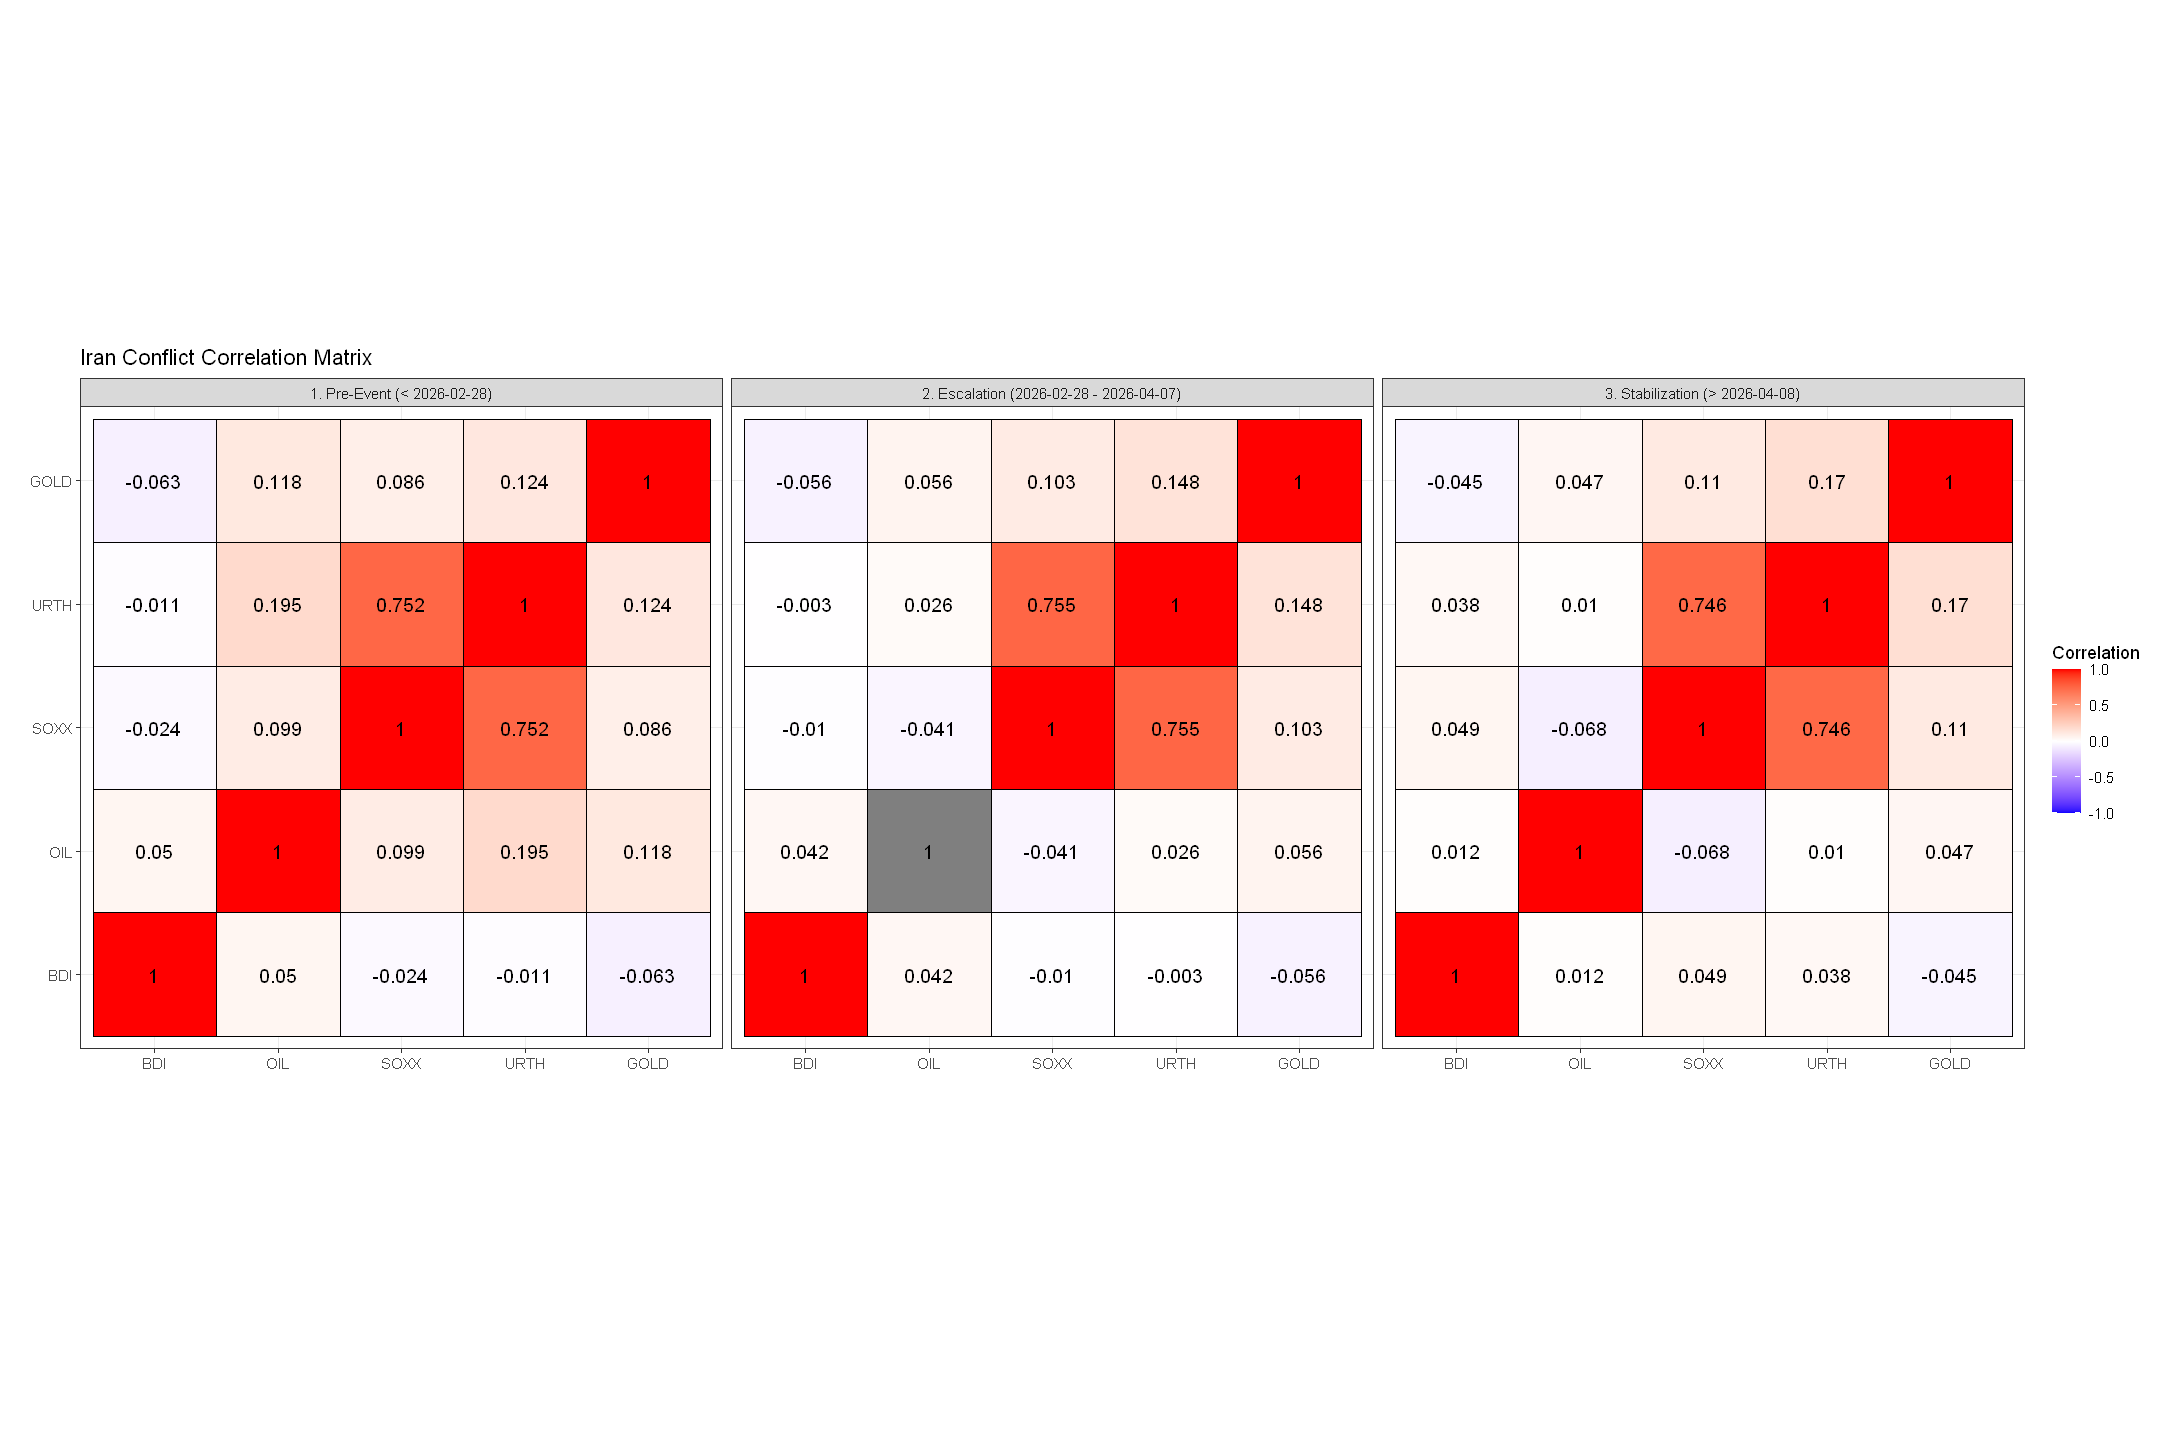

In [10]:
# Plot correlation matrix phases of all assets
ggplot(data = full_corr_matrix, aes(x = Var1, y = Var2, fill = mean_corr)) +
  geom_tile(color = "black", size = 0.1) + 
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", 
                       midpoint = 0, limit = c(-1,1), space = "Lab", 
                       name="Correlation") +
  geom_text(aes(label = round(mean_corr, 3)), 
          color = "black", size = 4) + 
  labs(x = "", y = "", title = "Iran Conflict Correlation Matrix") + 
  theme_bw() +
  coord_fixed() + 
  facet_wrap(~ state)

The three-panel heatmap illustrates the transition of mean conditional correlations across three distinct geopolitical regimes during the 2026 Iran-US conflict.

As previously mentioned, the most compelling evidence of a regime change is visible in the conditional correlation between OIL-SOXX and OIL-URTH. Both pairs show healthy positive correlations before the conflict, which then suddenly collapse to negative averages during escalation. Notably, even during stabilization (i.e., the cease-fire accord), the relationships between the assets fail to revert to their historical baselines, suggesting that the OIL prices continuously trade at a premium while ETF prices have recovered. 

Interestingly, the correlation between SOXX and URTH has remained relatively stable during the conflict, suggesting that the semiconductor industry remained closely integrated with broader global equity markets throughout the conflict period.